Numpy

In [26]:
import numpy as np

# X = matriz [-1, 1; 0, 2; 2, 0; 3, 3]
X = np.array([[-1, 1], 
             [0, 2], 
             [2, 0],
             [3, 3]])

print(X)

# N = número de filas de X

N = len(X)
N = X.shape[0]
print(N)

# mean = media de los datos

mean = X.mean(axis=0); mean

# X_tilde = X - media
X_tilde = X - mean
print(f'Broadcasting: {X.shape} - {mean.shape} -> {X_tilde.shape}')
X_tilde

# Sigma = matriz de covarianzas empírica calculada a partir de X_tilde

Sigma = 1/N * X_tilde.T @ X_tilde; print(Sigma, '\n', np.cov(X, rowvar=False, bias=True))
Sigma


[[-1  1]
 [ 0  2]
 [ 2  0]
 [ 3  3]]
4
Broadcasting: (4, 2) - (2,) -> (4, 2)
[[2.5  0.5 ]
 [0.5  1.25]] 
 [[2.5  0.5 ]
 [0.5  1.25]]


array([[2.5 , 0.5 ],
       [0.5 , 1.25]])

SCIPY

pdf = array 1d con la pdf de una normal 1d estándar en Y
Y = rejilla 2d de 3**2 puntos en [-1, 1]**2
pdf = array 2d con la pdf de una normal 2d estándar en Y

In [ ]:
from scipy import stats

# Y = array 1d con 10 muestras de una Bernoulli con probabilidad 0.25 de 1
Y1 = stats.bernoulli(0.25).rvs(10)
print(Y1)

[0 0 0 0 1 0 1 1 1 0]


In [ ]:
# Y = array 2d con 3 muestras de una categórica para 3 clases con probabilidades (0.3, 0.2, 0.5)

from scipy.stats import multinomial
Y2 = multinomial(1, [0.3, 0.2, 0.5]).rvs(3) #3 muestras y en cada muestra saca un valor 
print(Y2)

[[0 0 1]
 [0 1 0]
 [0 0 1]]


In [ ]:
# Y = array 1d con 5 muestras de una normal 1d estándar
from scipy.stats import norm
Y3 = stats.norm(0, 1).rvs(5)
Y3

array([-3.92797676, -1.28784599,  2.10945753,  0.03615811,  2.8713999 ])

In [ ]:
# Y = rejilla 1d de 5 puntos en [-1, 1]



Matplotlib

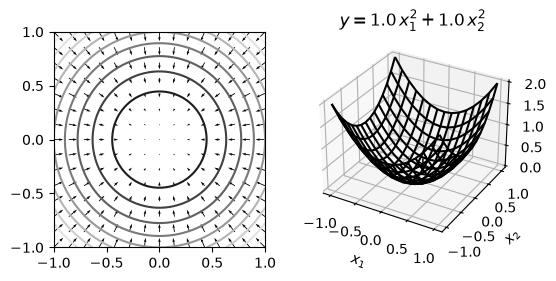

In [42]:

import numpy as np; import matplotlib.pyplot as plt

R = np.linspace(-1, 1, 50); X1, X2 = np.meshgrid(R, R); X = np.c_[np.ravel(X1), np.ravel(X2)]
a = np.array([1, 1]); Y = (np.square(X) @ a).reshape(X1.shape)

# dibujar la figura (pagina para la grafica)
fig = plt.figure(figsize=(6, 2.8))
ax = plt.subplot(121) #axis
ax.contour(X1, X2, Y, 10, cmap='Greys_r')


r = np.linspace(-1, 1, 15); x1, x2 = np.meshgrid(r, r); x = np.c_[np.ravel(x1), np.ravel(x2)]
neg_grad = -x @ np.diag(2*a)
ax.quiver(x[:,0], x[:,1], neg_grad[:,0], neg_grad[:,1], color='black', angles='xy') # arrows


ax = plt.subplot(122, projection='3d'); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'$y={a[0]:.1f}\\,x_1^2{a[1]:+.1f}\\,x_2^2$'); ax.text(0, 0, 0, '*', fontsize=20)
ax.plot_wireframe(x1, x2, a[0]*x1**2 + a[1]*x2**2, color='black');


Datasets

In [43]:
import numpy as np; import datasets
ds = datasets.load_dataset("ylecun/mnist").with_format("numpy"); ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [44]:
ds = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("numpy"); ds['train']


Dataset({
    features: ['image', 'label'],
    num_rows: 60000
})